In [ ]:
%pip install langchain_groq

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_groq import ChatGroq

import requests
import random

In [25]:
from google.colab import userdata
api_key = userdata.get('GROQ_API_KEY1')
api_key_2 = userdata.get('GROQ_API_KEY2')

In [26]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key,
    verbose=True,
    # other params...
)

subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key_2,
    verbose=True,
    # other params...
)

In [11]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [13]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [14]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

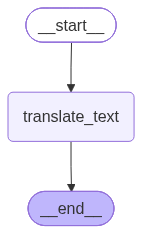

In [22]:
subgraph

In [15]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str


In [19]:
### node in parent graph to generate answer
def generate_answer(state: ParentState):

    answer = llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [18]:
### translate node in parent graph which execute the subgraph
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [20]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

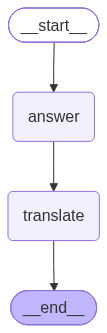

In [21]:
graph = parent_builder.compile()

graph

In [27]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how matter and energy behave at the smallest scales—typically at the level of atoms, electrons, photons, and other sub‑atomic particles.  \n\n### Why a new theory was needed\nClassical physics (Newtonian mechanics, Maxwell’s electromagnetism, thermodynamics) works extremely well for everyday objects, but it fails to explain several phenomena observed in the early 20th\u202fcentury, such as:\n\n| Phenomenon | Classical prediction | What was observed |\n|------------|----------------------|-------------------|\n| Black‑body radiation | Infinite energy at short wavelengths (the “ultraviolet catastrophe”) | Finite spectrum that peaks at a wavelength that depends on temperature |\n| Photoelectric effect | Light of any intensity should eject electrons | Only light above a certain frequency (color) ejects electrons, regardless of